In [1]:
import redback 
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import Planck18 as cosmo 
import astropy.units as uu
from redback.transient_models.supernova_models import lambda_to_nu
import redback.interaction_processes as ip
import redback.sed as sed
import redback.photosphere as photosphere

import astropy.units as uu

import extinction
from extinction import ccm89, fitzpatrick99, apply, remove
from scipy.interpolate import RegularGridInterpolator
import sncosmo

No module named 'lalsimulation'
lalsimulation is not installed. Some EOS based models will not work. Please use bilby eos or pass your own EOS generation class to the model
14:08 bilby INFO    : Running bilby version: 2.3.0
14:08 redback INFO    : Running redback version: 1.12.1


In [2]:
def sn1998bw_template(time, redshift, amplitude, **kwargs):
    """
    A wrapper to the SN1998bw template. Only valid between 1100-11000 Angstrom and 0.01 to 90 days post explosion in rest frame

    Parameters
    ----------
    time
        time in days in observer frame (post explosion)
    redshift
        redshift
    amplitude
        amplitude scaling factor, where 1.0 is the original brightness of SN1998bw; and f_lambda is scaled by this factor
    kwargs
        Additional keyword arguments required by redback.
    frequency
        Required if output_format is 'flux_density'. frequency to calculate - Must be same length as time array or a single number).
    bands
        Required if output_format is 'magnitude' or 'flux'.
    output_format
        'flux_density', 'magnitude', 'spectra', 'flux', 'sncosmo_source'
    cosmology
        Cosmology to use for luminosity distance calculation. Defaults to Planck18. Must be a astropy.cosmology object.
    Returns
    -------
        set by output format - 'flux_density', 'magnitude', 'spectra', 'flux', 'sncosmo_source'

    """
    import sncosmo
    model = sncosmo.Model(source='v19-1998bw')
    original_redshift = 0.0085
    cosmology = kwargs.get("cosmology", cosmo)
    original_dl = (43*uu.Mpc).to(uu.cm).value

    # From roughly matching to Galama+ or Clocchiatti+1998bw light curves
    original_peak_time = 15
    model.set(z=original_redshift, t0=original_peak_time)
    model.set_source_peakmag(14.25, band='bessellb', magsys='ab')
    tts = np.geomspace(0.01, 90, 200)
    lls = np.linspace(1620, 11000, 300)
    f_lambda = model.flux(tts, lls) #erg/s/cm^2/Angstrom.
    l_lambda = f_lambda * 4 * np.pi * original_dl**2  # erg/s/Angstrom

    # We consider this the rest frame spectrum of 1998bw. Now we can redshift it and scale it.
    time_obs = tts * (1 + redshift)
    lambda_obs = lls * (1 + redshift)
    dl_new = cosmology.luminosity_distance(redshift).cgs.value
    f_lambda_obs = l_lambda / (4 * np.pi * dl_new**2)
    f_lambda_obs = amplitude * f_lambda_obs * (1 + redshift) # accounting for bandwidth stretching
    f_lambda_obs = f_lambda_obs * uu.erg / uu.s / uu.cm ** 2 / uu.Angstrom
    if kwargs['output_format'] == 'flux_density':
        frequency = kwargs['frequency']
        # work in obs frame
        ff_array = lambda_to_nu(lambda_obs)

        # Convert flux density to mJy
        fmjy = f_lambda_obs.to(uu.mJy, equivalencies=uu.spectral_density(wav=lambda_obs * uu.Angstrom)).value
        # Create interpolator on obs frame grid
        flux_interpolator = RegularGridInterpolator(
            (time_obs, ff_array),
            fmjy,
            bounds_error=False,
            fill_value=0.0)

        # Prepare points for interpolation
        if isinstance(frequency, (int, float)):
            frequency = np.ones_like(time) * frequency

        # Create points for evaluation
        points = np.column_stack((time, frequency))

        # Return interpolated flux density with (1+z) correction for observer frame
        return flux_interpolator(points)
    elif kwargs['output_format'] == 'spectra':
        return namedtuple('output', ['time', 'lambdas', 'spectra'])(time=time_obs,
                                                                    lambdas=lambda_obs,
                                                                    spectra=f_lambda_obs)
    else:
        return sed.get_correct_output_format_from_spectra(time=time, time_eval=time_obs,
                                                          spectra=f_lambda_obs, lambda_array=lambda_obs,
                                                          **kwargs)



In [3]:
# After pasting the function definition into your cell:
from redback.model_library import all_models_dict

all_models_dict['sn1998bw_template'] = sn1998bw_template

# Now any redback functions that look in the dictionary will find it!

In [20]:
func = all_models_dict['sn1998bw_template']

time = np.array((90)) #worked for np.array([11]) so works for all other times ?
red = 0.0085 #redshift of arbitrary event (in this case we just wanted f_1998bw = 1 )
freq = 3e14 #lower limit = 2.75e14 - if 2.0e14 does this give inf ?? YES - BE VERY CAREFUOL WITH THE FREQUENCY RANGES !! 

sn_1998b2 = func(time=time,redshift=red,amplitude=1.0,frequency=freq,output_format='flux_density', cosmology=cosmo)
sn_1998b1 = func(time=time,redshift=0.0085,amplitude=1.0,frequency=freq,output_format='flux_density', cosmology=cosmo)

print(sn_1998b2, sn_1998b1, sn_1998b2/sn_1998b1)

[0.12421773] [0.12421773] [1.]


In [5]:
#THIS WORKS !! ???!!! WHEN z = 0.085, but when z = 0.0085(tru redshift) model is still correct !! YAY 

#BETWEEN FREQUENCIES 3E14 - 1E15 THIS RETURNS F_98 VALUE WHICH IS CORRECT !! 
#DOES THIS WORK FOR ALL TIMES ? SHOULD DO !  works at anothing from 0.02 and above upto 90 (95)

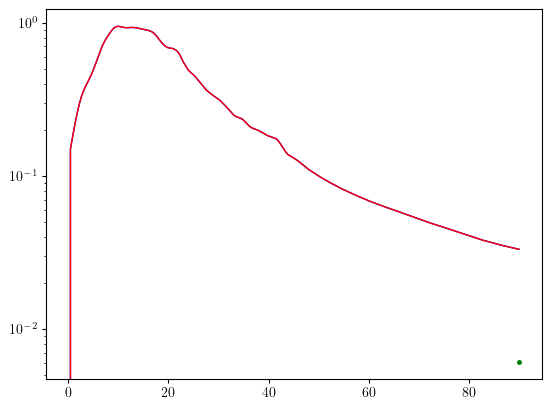

In [18]:
#Print out a graph of the lightcurve to check what is going on: 
#TESTING TO GET F_98 = 1 !! 

#WHAT FREQUENCY GETS THIS TO B F_98 = 1? 
#use jillians values ? 
freq = 1e15
redshift = 0.0085
times = np.linspace(0.01,90,200)
sn_1998bw = func(time=times,redshift=redshift,amplitude=1.0,output_format='flux_density',frequency=freq)
sn_1998bw1 = func(time=times,redshift=0.0085,amplitude=1.0,frequency=freq,output_format='flux_density')

plt.semilogy(times,sn_1998bw,'-b')
plt.semilogy(times,sn_1998bw1, '-r')
#this point is the arbitrary GRB event at the epoch 
plt.semilogy(time,sn_1998b1, marker='o',color='green')
#plt.ylim(19,13)
plt.show()

In [23]:
#now testing has been done for 1998bw, do the same for another event we have info for with known values !! 
#TAKE AN EVENT WE HAVE LATE TIME DATA FOR 

event_name = '171205A'
AB_mag = 17.7
red = 0.0368
time = np.array(10.98)
freq = 3.74100e+14
# band = 'besselli'
a_v = 0.05 * 3.1 #E(B-V) x R_v (0.155)

wavelength =  np.array([8020.14000]) #angstroms

#convert AB magnitude of arbitrary GRB event --> flux density (mJy)
def calc_flux_density_from_ABmag(AB_mag):
    """
    Calculate flux density from AB magnitude assuming monochromatic AB filter

    :param magnitudes: AB magnitude values
    :return: flux density
    """
    return (AB_mag * uu.ABmag).to(uu.mJy)

flux_density_event = calc_flux_density_from_ABmag(AB_mag)
print("This is the flux density of  GRB event", event_name ,f"without extinction correction: {flux_density_event:.5f}")

#de-redden flux density, account for extinction if necessary 
dereddened_flux_event = extinction.remove(fitzpatrick99(wavelength, a_v, 3.1),flux_density_event)
print(f"This is the extinction corrected GRB event flux density found using fitzpatrick99: {dereddened_flux_event[0]:.5f}")

This is the flux density of  GRB event 171205A without extinction correction: 0.30200 mJy
This is the extinction corrected GRB event flux density found using fitzpatrick99: 0.32671 mJy


In [24]:
#for 171205A
func = all_models_dict['sn1998bw_template']

time = np.array((10.98)) #worked for np.array([11]) so works for all other times ?
red = 0.0368 #redshift of 171205A
freq = 3.74100e+14

sn_1998b2 = func(time=time,redshift=red,amplitude=1.0,frequency=freq,output_format='flux_density', cosmology=cosmo) #artibtrary GRB
sn_1998b1 = func(time=time,redshift=0.0085,amplitude=1.0,frequency=freq,output_format='flux_density', cosmology=cosmo) #SN1998bw

print(sn_1998b2, sn_1998b1, sn_1998b2/sn_1998b1)

#extinction corrected flux frac: 
print(dereddened_flux_event[0], sn_1998b1, dereddened_flux_event[0]/sn_1998b1)

#NOTE! THIS DOESNT DO ANY DE-REDENING ETC. - DOES IT GIVE VALUES CLOSER TO WHAT ANDREW GOT ? 
#andrew gets 71205A f_98 = 0.5 !! so yes 0.48 is very close !! - factor of 10 too small ????? 
#what if i just fractioned it over its known flux density with extinction correction applied ? -- similar result !! 
#code currently working but only takes in redshift, frequency and time - not extinction ?? can i get away with this ? see if i am close to andrew for any other values 

[0.32477057] [6.71104592] [0.04839344]
0.32670990734268895 mJy [6.71104592] [0.04868241] mJy


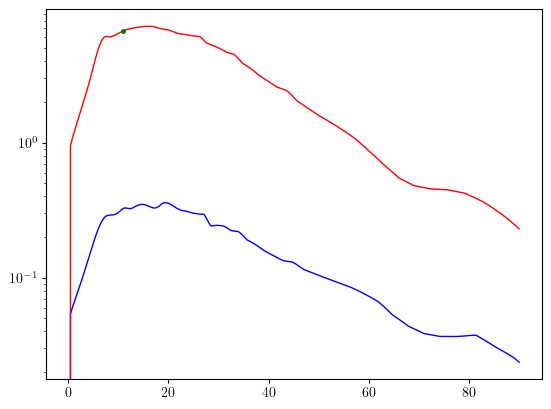

In [22]:
#PLOT TO SEE HOW THIS LOOKS GRAPHICALLY 
freq = freq
redshift = red
times = np.linspace(0.01,90,200)
sn_1998bw = func(time=times,redshift=redshift,amplitude=1.0,output_format='flux_density',frequency=freq)
sn_1998bw1 = func(time=times,redshift=0.0085,amplitude=1.0,frequency=freq,output_format='flux_density')

plt.semilogy(times,sn_1998bw,'-b')
plt.semilogy(times,sn_1998bw1, '-r')
#this point is the arbitrary GRB event at the epoch 
plt.semilogy(time,sn_1998b1, marker='o',color='green')
#plt.ylim(19,13)
plt.show()

In [34]:
#NOW TRYING AN UNKNOWN EVENT ! 
#need much later time !! 

event_name = '231117A'
red = 0.257
epoch = np.array(1.32) #lowest possible time - short GRB - increase to 0.1
frequency = 4.85800e+14 #match freq to redback filter band 
AB_mag = 20.86 # WAY TOO BIG TO COMPARE TO 1998BW !! - USE MUCH LATER TIME 
a_v = 0.186 #E(B-V) x R_v
wavelength= np.array([6175.58000])

#convert AB magnitude of arbitrary GRB event --> flux density (mJy)
def calc_flux_density_from_ABmag(AB_mag):
    """
    Calculate flux density from AB magnitude assuming monochromatic AB filter

    :param magnitudes: AB magnitude values
    :return: flux density
    """
    return (AB_mag * uu.ABmag).to(uu.mJy)

flux_density_event = calc_flux_density_from_ABmag(AB_mag)
print("This is the flux density of  GRB event", event_name ,f"without extinction correction: {flux_density_event:.5f}")

#de-redden flux density, account for extinction if necessary 
dereddened_flux_event = extinction.remove(fitzpatrick99(wavelength, a_v, 3.1),flux_density_event)
print(f"This is the extinction corrected GRB event flux density found using fitzpatrick99: {dereddened_flux_event[0]:.5f}")


func = all_models_dict['sn1998bw_template']

time = epoch #worked for np.array([11]) so works for all other times ?
red = red #redshift of 231117A
freq = frequency

sn_1998b2 = func(time=time,redshift=red,amplitude=1.0,frequency=freq,output_format='flux_density', cosmology=cosmo) #artibtrary GRB
sn_1998b1 = func(time=time,redshift=0.0085,amplitude=1.0,frequency=freq,output_format='flux_density', cosmology=cosmo) #SN1998bw

#which result is more similar to andrew ? 
#using model - no extinction 
print(sn_1998b2, sn_1998b1, sn_1998b1/sn_1998b2) #HAS TO BE 1/2 DID GAVIN HAVE THINGS THE OTHER WAY ROUND ?? 

#extinction corrected flux frac: 
print(f"{dereddened_flux_event[0]:.5f}", sn_1998b1, dereddened_flux_event[0]/sn_1998b2)

#NOW WHEN I SWITCH 2/1 TO BE 1/2 I GET CRAZY RESULTS ?! 

This is the flux density of  GRB event 231117A without extinction correction: 0.01644 mJy
This is the extinction corrected GRB event flux density found using fitzpatrick99: 0.01896 mJy
[0.00376184] [2.51585897] [668.78444559]
0.01896 mJy [2.51585897] [5.04092406] mJy


In [ ]:
#why are the two outputs for flux density of the GRB event without extinction so different ? 
#flux = 0.01644 
#dereddened =  0.0189631 ??
#flux of arbitrary GRB in model = 0.00376184

#which is the correct method ? is it wrong to run the GB through the model ? should we get the flux from it another way like just from online ? 
#what is this actually doing ? sn_1998b2 = func(time=time,redshift=red,amplitude=1.0,frequency=freq,output_format='flux_density', cosmology=cosmo) #artibtrary GRB

In [30]:
#test more known events to match andrewsvalues - see if model should be predicting the GRB's flux density or if we should be getting it from online ? 
event_name = '060218'
AB_mag = 17.22
redshift = 0.0335
epoch = np.array([11.0])  # Days in observer frame
a_v = 0.39 #true value from literature 
frequency = 4.61700e+14 #besselr 
wavelength = np.array([6498.09000]) #angstroms

#convert AB magnitude of arbitrary GRB event --> flux density (mJy)
def calc_flux_density_from_ABmag(AB_mag):
    """
    Calculate flux density from AB magnitude assuming monochromatic AB filter

    :param magnitudes: AB magnitude values
    :return: flux density
    """
    return (AB_mag * uu.ABmag).to(uu.mJy)

flux_density_event = calc_flux_density_from_ABmag(AB_mag)
print("This is the flux density of  GRB event", event_name ,f"without extinction correction: {flux_density_event:.5f}")

#de-redden flux density, account for extinction if necessary 
dereddened_flux_event = extinction.remove(fitzpatrick99(wavelength, a_v, 3.1),flux_density_event)
print(f"This is the extinction corrected GRB event flux density found using fitzpatrick99: {dereddened_flux_event[0]:.5f}")


func = all_models_dict['sn1998bw_template']

time = epoch 
red = redshift #redshift of 060218
freq = frequency

sn_1998b2 = func(time=time,redshift=red,amplitude=1.0,frequency=freq,output_format='flux_density', cosmology=cosmo) #artibtrary GRB
sn_1998b1 = func(time=time,redshift=0.0085,amplitude=1.0,frequency=freq,output_format='flux_density', cosmology=cosmo) #SN1998bw

#which result is more similar to andrew ? 
#using model - no extinction 
print(sn_1998b2, sn_1998b1, sn_1998b2/sn_1998b1)

#extinction corrected flux frac: 
print(f"{dereddened_flux_event[0]:.5f}", sn_1998b1, dereddened_flux_event[0]/sn_1998b1)

#andrew gets 0.7 ?? i get 0.07 ?? 


This is the flux density of  GRB event 060218 without extinction correction: 0.46989 mJy
This is the extinction corrected GRB event flux density found using fitzpatrick99: 0.62005 mJy
[0.67001504] [10.16906487] [0.06588758]
0.62005 mJy [10.16906487] [0.06097454] mJy


In [32]:
#retry for 060218 but using Jillian's data: 
#jillians data is all in U,B,V,R,I so have to convert from vega --> AB ?  do anyway and see if there is a difference ? YES small difference 

#are we any closer to andrews value ? not really - returning 0.06 and 0.01 ?? is andrews value wrong ?? 
#run all of them through my code to see what i get -.e. all gold ones 

#take the latest time to compare to 1998bw + assume all data = extinction corrected

event_name = '060218'
AB_mag = 19.2
#AB_mag = mag -0.09  #correction in the B band 
redshift = 0.0335
epoch = np.array([22.965])  # Days in observer frame
a_v = 0 #jillian's data 
frequency = 6.86300e+14 # B band 
wavelength = np.array([4371.07000]) #angstroms 


#convert AB magnitude of arbitrary GRB event --> flux density (mJy)
def calc_flux_density_from_ABmag(AB_mag):
    """
    Calculate flux density from AB magnitude assuming monochromatic AB filter

    :param magnitudes: AB magnitude values
    :return: flux density
    """
    return (AB_mag * uu.ABmag).to(uu.mJy)

flux_density_event = calc_flux_density_from_ABmag(AB_mag)
print("This is the flux density of  GRB event", event_name ,f"without extinction correction: {flux_density_event:.5f}")

#de-redden flux density, account for extinction if necessary 
dereddened_flux_event = extinction.remove(fitzpatrick99(wavelength, a_v, 3.1),flux_density_event)
print(f"This is the extinction corrected GRB event flux density found using fitzpatrick99: {dereddened_flux_event[0]:.5f}")


func = all_models_dict['sn1998bw_template']

time = epoch 
red = redshift #redshift of 060218
freq = frequency

sn_1998b2 = func(time=time,redshift=red,amplitude=1.0,frequency=freq,output_format='flux_density', cosmology=cosmo) #artibtrary GRB
sn_1998b1 = func(time=time,redshift=0.0085,amplitude=1.0,frequency=freq,output_format='flux_density', cosmology=cosmo) #SN1998bw

#which result is more similar to andrew ? 
#using model - no extinction 
print(sn_1998b2, sn_1998b1, sn_1998b2/sn_1998b1)

#extinction corrected flux frac: 
print(f"{dereddened_flux_event[0]:.5f}", sn_1998b1, dereddened_flux_event[0]/sn_1998b1)



This is the flux density of  GRB event 060218 without extinction correction: 0.07586 mJy
This is the extinction corrected GRB event flux density found using fitzpatrick99: 0.07586 mJy
[0.42945648] [6.49677938] [0.06610298]
0.07586 mJy [6.49677938] [0.01167621] mJy
